# [**Kaggle - Sleep Dataset**](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset/data)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

plt.style.use('ggplot')



df = pd.read_csv('data/sleep_health.csv')
df


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


## EDA & Preprocessing



In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 49.2 KB


In [3]:
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [4]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Sleep Disorder'].unique()

<ArrowStringArray>
[nan, 'Sleep Apnea', 'Insomnia']
Length: 3, dtype: str

The only feature to have missing values is the `Sleep Disorder`, but it seems like None was set to `Nan`. So we don't have any missing values afterall

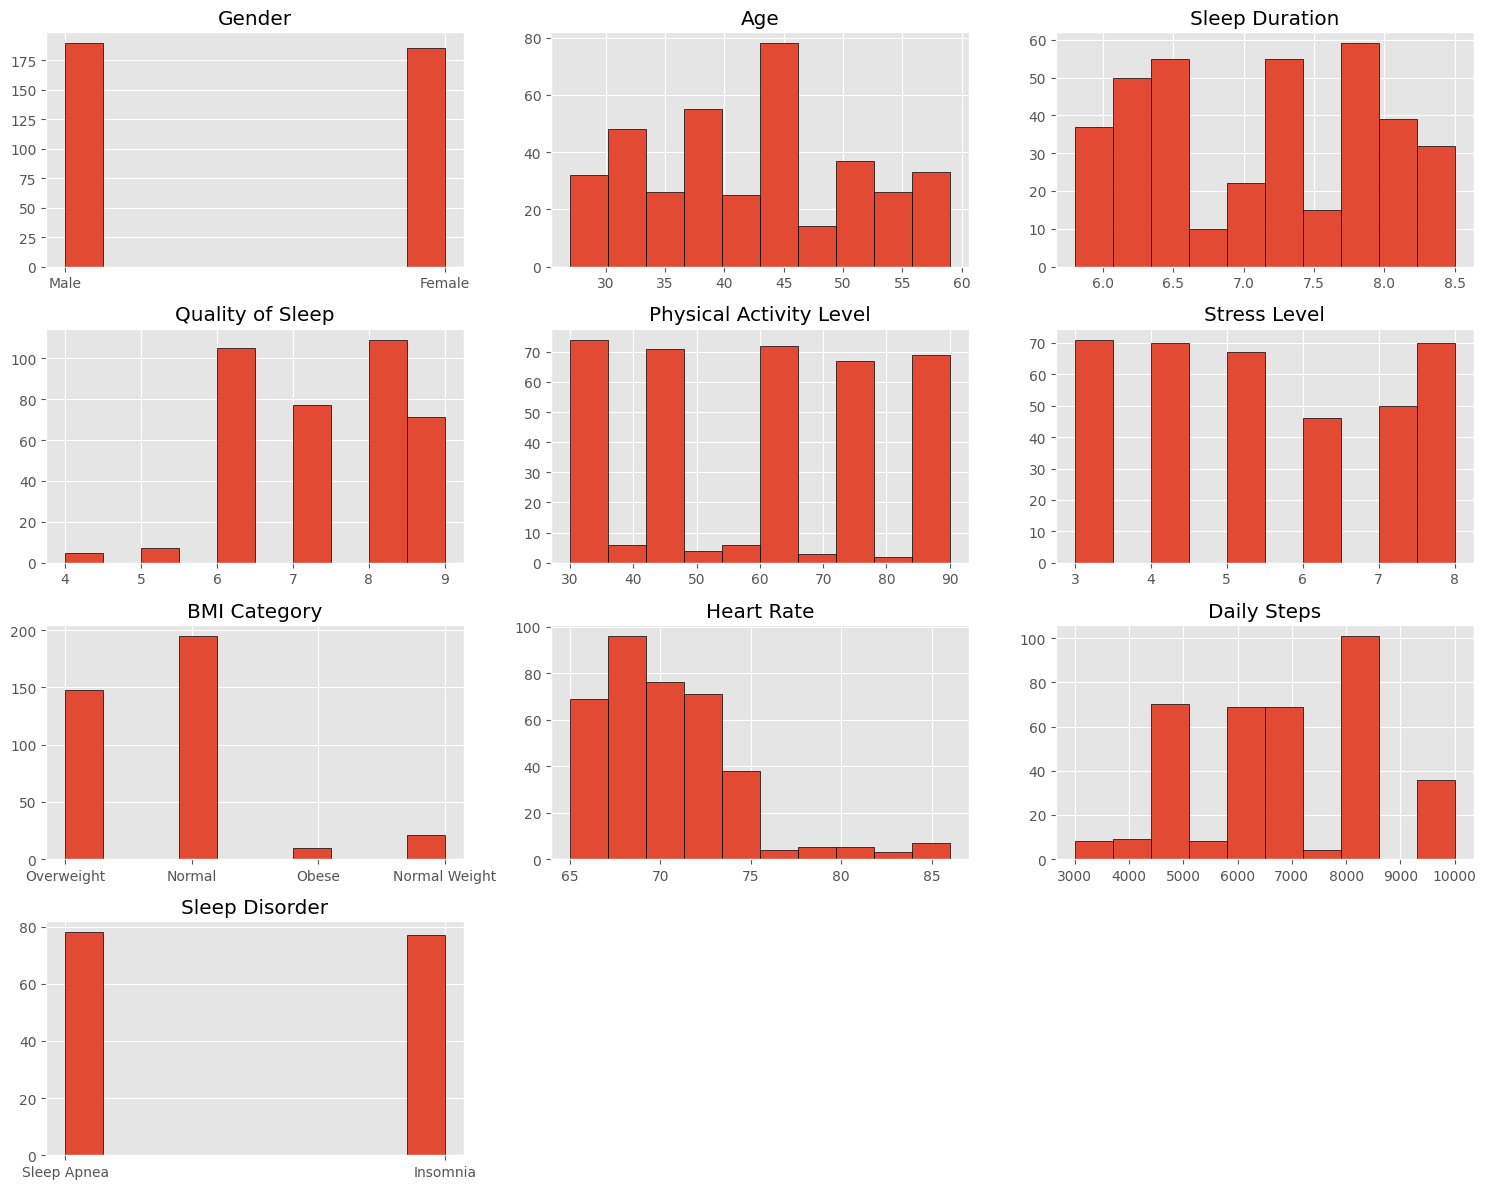

In [7]:
import math
column = [c for c in df.columns if c not in ['Person ID', 'Blood Pressure', 'Occupation']]

cols_per_row = 3
rows = math.ceil(len(column)/ cols_per_row)

plt.figure(figsize = (15,12))

for count, col in enumerate(column):
  plt.subplot(rows, cols_per_row, count+1)
  df[col].hist(edgecolor = 'black')
  plt.title(col)

plt.tight_layout()
plt.show()

We have a weird split between `Normal` and `Normal Weight`. So let's check

In [8]:
df.groupby("BMI Category").agg(
    count = ("Person ID", "count"),
    avg_age=("Age", "mean"),
    avg_sleep_duration=("Sleep Duration", "mean"),
    avg_sleep_quality=("Quality of Sleep", "mean"),
    avg_stress=("Stress Level", "mean"),
    avg_heart_rate=("Heart Rate", "mean"),
)



,count,avg_age,avg_sleep_duration,avg_sleep_quality,avg_stress,avg_heart_rate
BMI Category,,,,,,
Normal,195,38.482051,7.393846,7.661538,5.128205,68.728205
Normal Weight,21,38.380952,7.333333,7.428571,5.190476,71.285714
Obese,10,38.000000,6.960000,6.400000,5.700000,84.300000
Overweight,148,47.885135,6.770270,6.898649,5.729730,70.945946


So it seems like a small number was incorrectly labeled as `Normal Weight` instead of just `Normal` so we will merge them

In [9]:
bmi_mapping = {
    'Normal' : 0,
    'Normal Weight': 0,
    'Overweight': 1,
    'Obese': 2
}

df['BMI Category'] = df['BMI Category'].map(bmi_mapping)

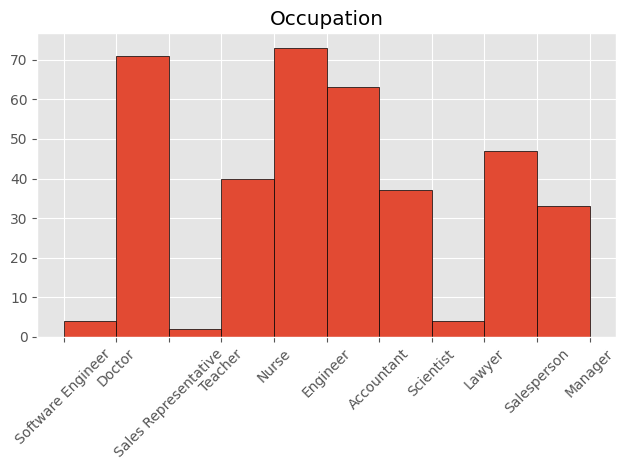

In [10]:
df['Occupation'].hist(edgecolor = 'black')
plt.title('Occupation')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

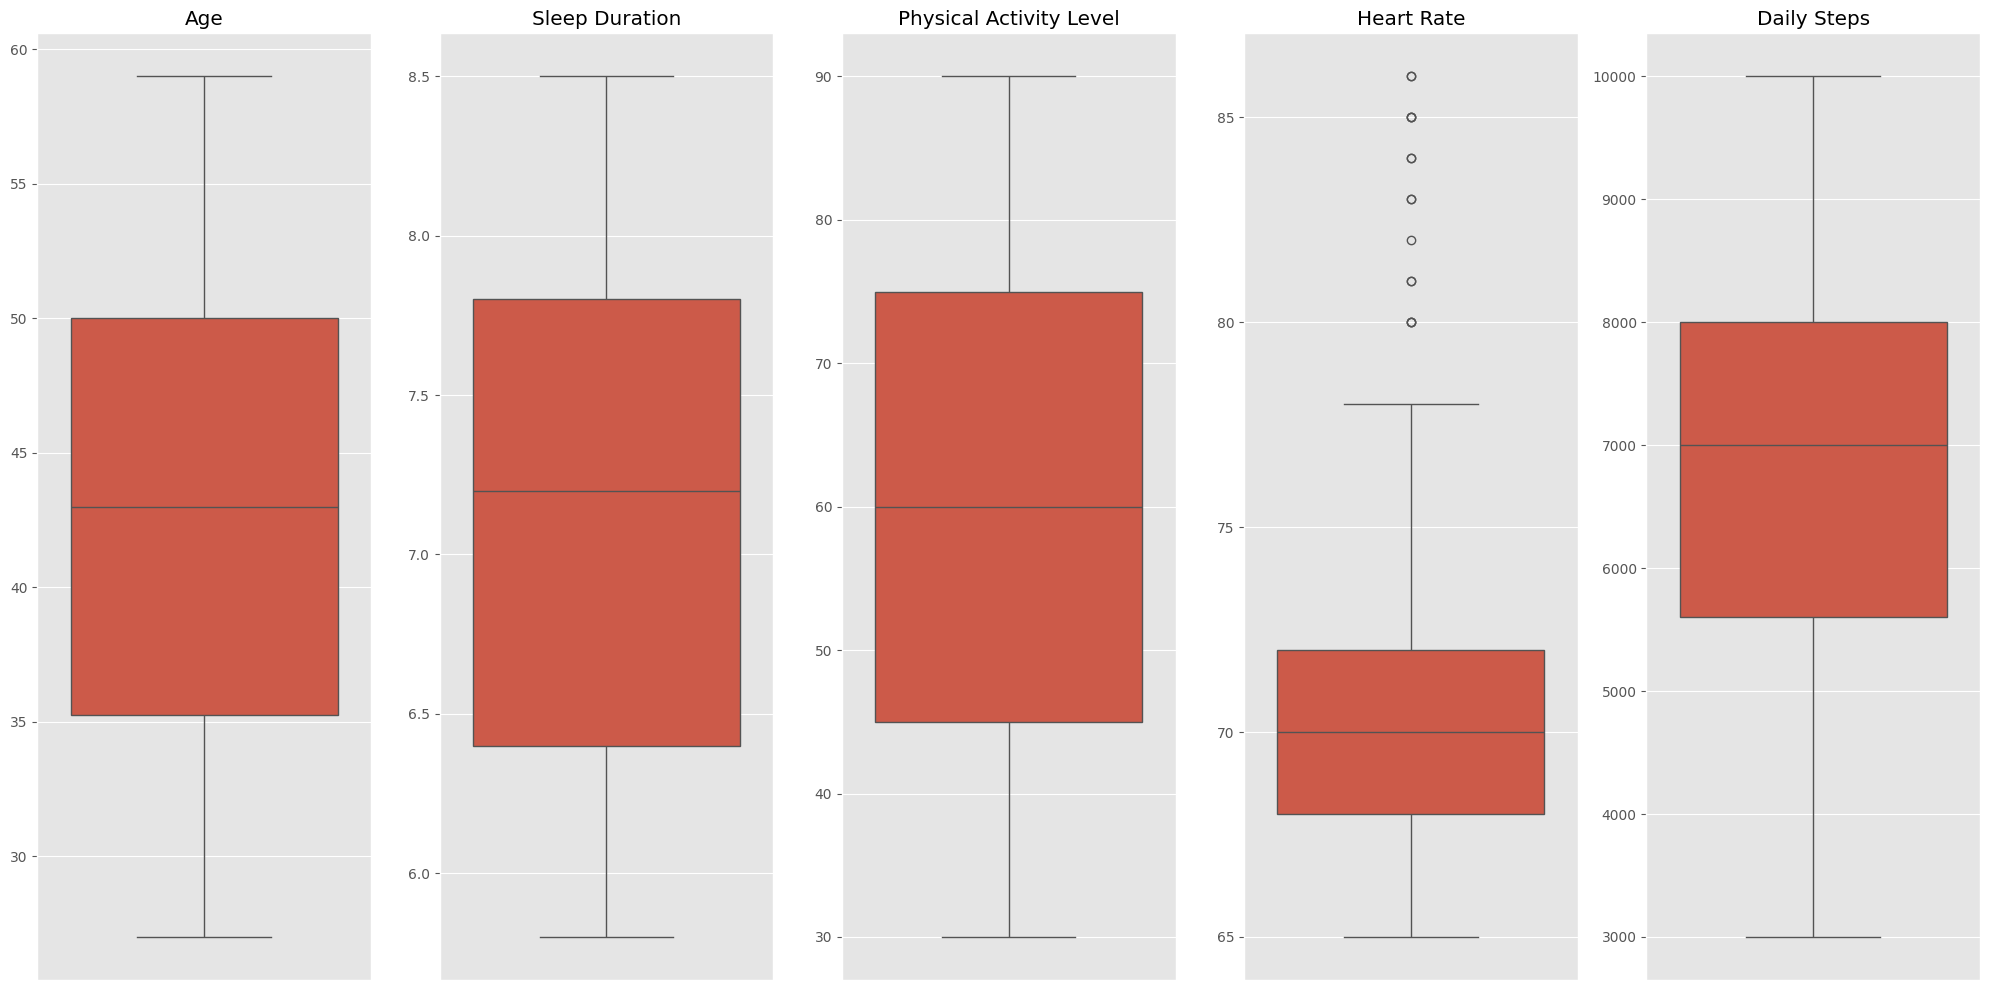

In [11]:
columns_to_plot = ['Age', 'Sleep Duration', 'Physical Activity Level', 'Heart Rate', 'Daily Steps']

fig, axes = plt.subplots(ncols=len(columns_to_plot), figsize=(20, 10))

for column, axis in zip(columns_to_plot, axes):
    sns.boxplot(data=df[column], ax=axis)
    axis.set_title(column)
    axis.set(xticklabels=[], xticks=[], ylabel="")

plt.tight_layout()
plt.show()

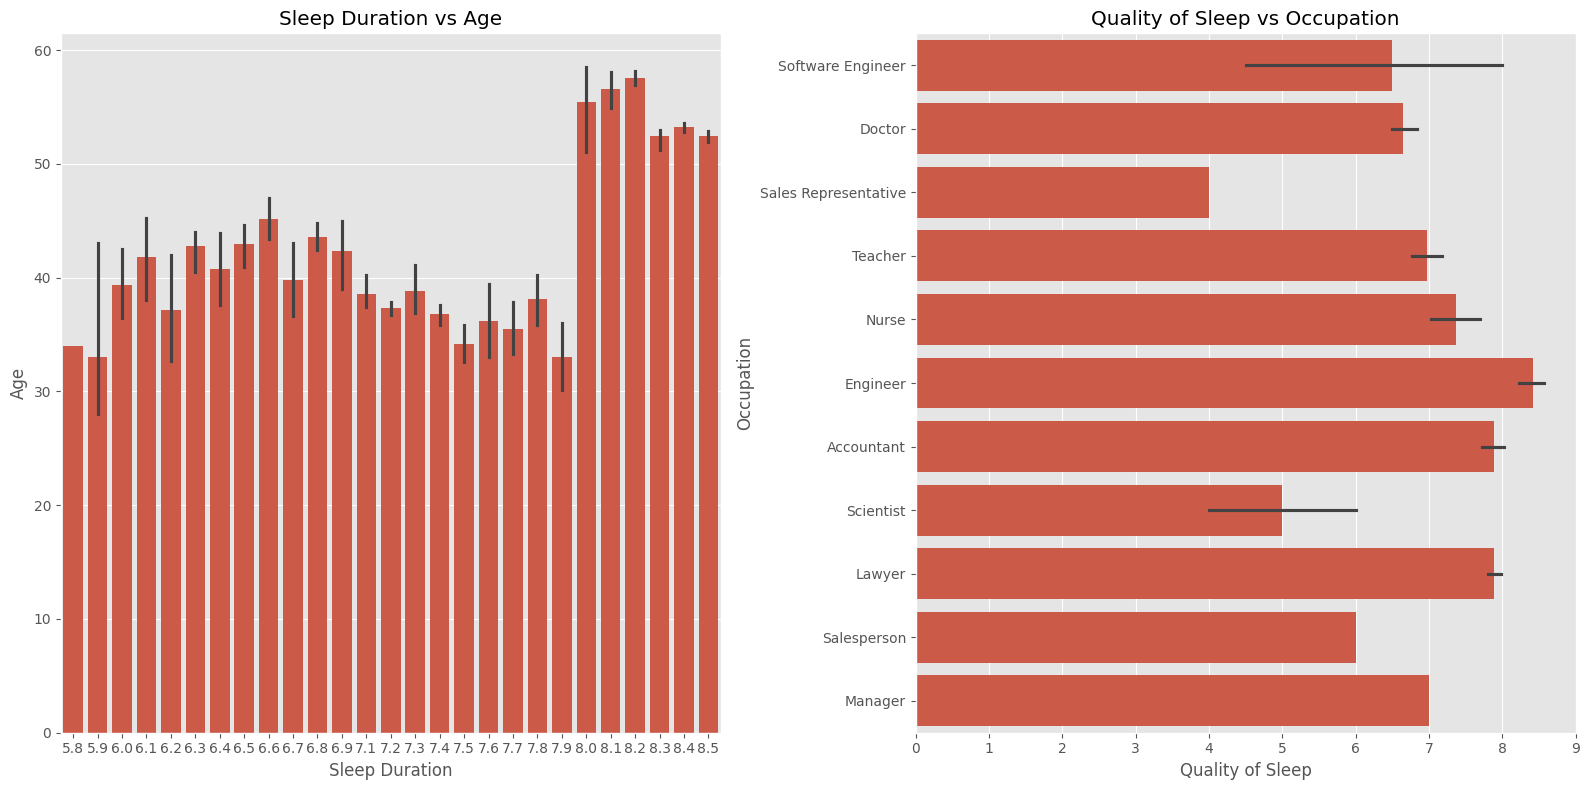

In [12]:
plt.figure(figsize = (16,8))

plt.subplot(1, 2, 1)
sns.barplot(df, x = 'Sleep Duration', y = 'Age')
plt.title("Sleep Duration vs Age")


plt.subplot(1, 2, 2)
sns.barplot(df, x = 'Quality of Sleep', y = 'Occupation')
plt.title("Quality of Sleep vs Occupation")
plt.tight_layout()
plt.show()



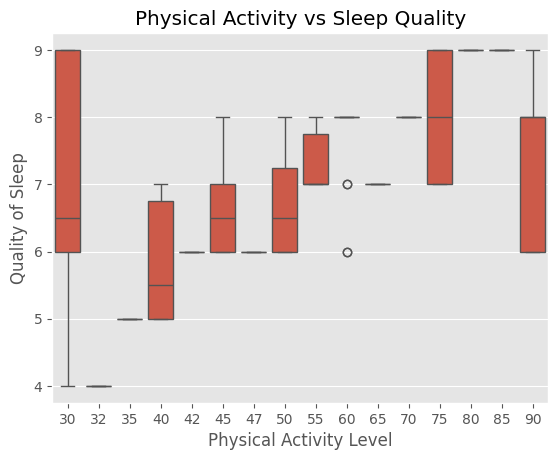

In [13]:
# phsical activitiy and sleep quality
sns.boxplot(
    x="Physical Activity Level",
    y="Quality of Sleep",
    data=df
)
plt.title("Physical Activity vs Sleep Quality")
plt.show()


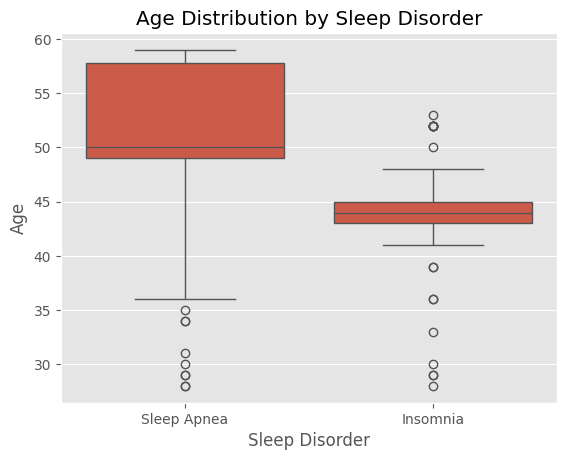

In [14]:
plt.figure()
sns.boxplot(
    x="Sleep Disorder",
    y="Age",
    data=df
)
plt.title("Age Distribution by Sleep Disorder")
plt.show()


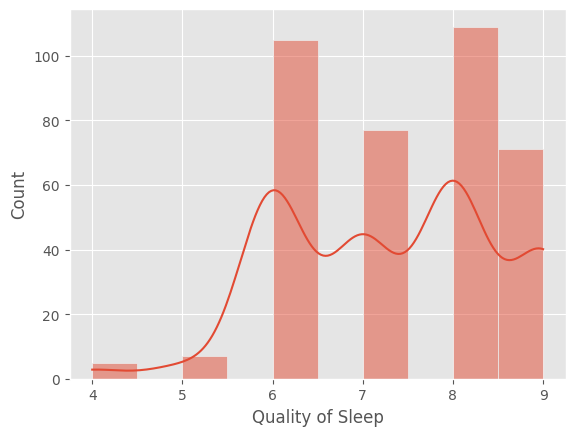

In [15]:
sns.histplot(df, x = 'Quality of Sleep', kde = True)
plt.show()

In [16]:
occupation_summary = (
    df.groupby("Occupation")
    .agg(
        avg_sleep_duration=("Sleep Duration", "mean"),
        avg_sleep_quality=("Quality of Sleep", "mean"),
        avg_stress=("Stress Level", "mean")
    )
    .sort_values("avg_sleep_quality")
)

occupation_summary


,avg_sleep_duration,avg_sleep_quality,avg_stress
Occupation,,,
Sales Representative,5.900000,4.000000,8.000000
Scientist,6.000000,5.000000,7.000000
Salesperson,6.403125,6.000000,7.000000
Software Engineer,6.750000,6.500000,6.000000
Doctor,6.970423,6.647887,6.732394
Teacher,6.690000,6.975000,4.525000
Manager,6.900000,7.000000,5.000000
Nurse,7.063014,7.369863,5.547945
Accountant,7.113514,7.891892,4.594595


Let's check the features that would need to be encoded

In [17]:
df['Occupation'].unique()

<ArrowStringArray>
[   'Software Engineer',               'Doctor', 'Sales Representative',
              'Teacher',                'Nurse',             'Engineer',
           'Accountant',            'Scientist',               'Lawyer',
          'Salesperson',              'Manager']
Length: 11, dtype: str

In [18]:
df['Blood Pressure'].unique()

<ArrowStringArray>
['126/83', '125/80', '140/90', '120/80', '132/87', '130/86', '117/76',
 '118/76', '128/85', '131/86', '128/84', '115/75', '135/88', '129/84',
 '130/85', '115/78', '119/77', '121/79', '125/82', '135/90', '122/80',
 '142/92', '140/95', '139/91', '118/75']
Length: 25, dtype: str

We can split `Blood Pressure` into `Systolic` and `Diastolic`

Notice we have `Normal` and `Normal weight` at the same time. statiscallly checking if they are the same or different

It looks like `gender` and `Blood Pressure` will need special care

- `gender` will convert to boolean value (turn to `int`)

In [19]:
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand = True).astype(int)
df['is_Male'] = (df['Gender'] == "Male").astype(int)

df = df.drop(columns = ['Blood Pressure', 'Gender'])

In [20]:
df.columns

Index(['Person ID', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate',
       'Daily Steps', 'Sleep Disorder', 'Systolic', 'Diastolic', 'is_Male'],
      dtype='str')

## Classification
Let's set up some **correlation matrix**

We are going to predict `Sleep Duration` since `Sleep quality` is subjective 

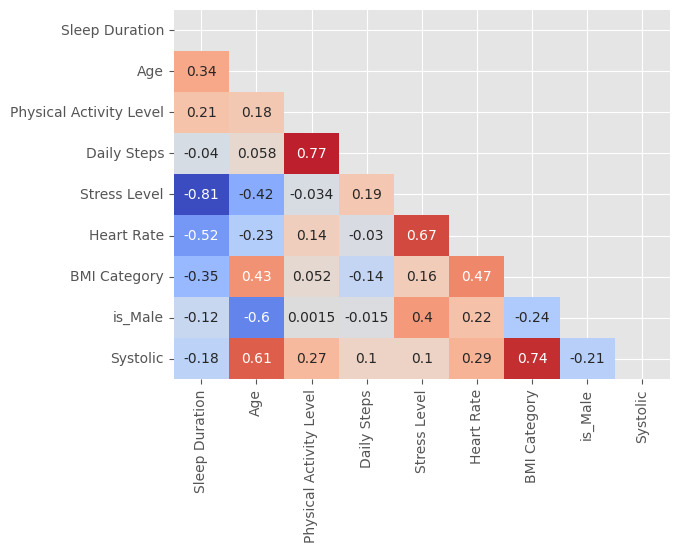

In [21]:
corr_df = df[['Sleep Duration',
              'Age',
              'Physical Activity Level',
              'Daily Steps',
              'Stress Level',
              'Heart Rate',
              'BMI Category',
              'is_Male',
              'Systolic']].copy()


matrix = corr_df.corr()

mask = np.triu(np.ones_like(matrix, dtype=bool))

sns.heatmap(matrix, mask = mask, cmap = 'coolwarm', annot = True, center = 0, cbar = False)

plt.show()

`Stress` has very high correlation, so we will remove it, since it would dominate over every other features. We are also going to bin our target

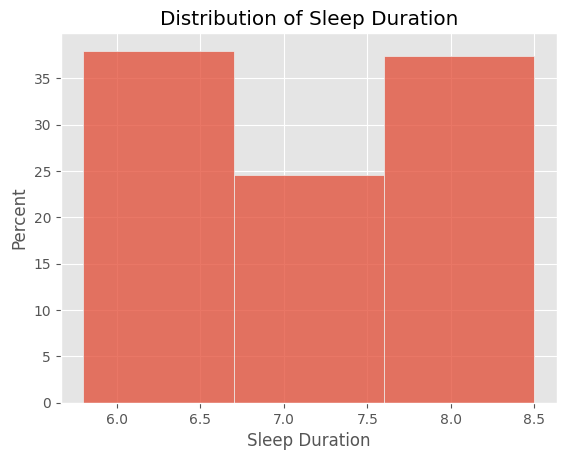

In [ ]:

# Histogram
sns.histplot(df, x = "Sleep Duration", bins=3, stat = 'percent')
plt.title('Distribution of Sleep Duration')

plt.show()

In [23]:
df['Sleep Target'] = pd.qcut(df['Sleep Duration'], q= 3, labels= [0, 1, 2]).astype(int)

# Group by the new target and look at the Sleep Duration stats
ranges = df.groupby('Sleep Target')['Sleep Duration'].agg(['min', 'max', 'count'])
print(ranges)

              min  max  count
Sleep Target                 
0             5.8  6.6    142
1             6.7  7.7    126
2             7.8  8.5    106


Now we are setting up preprocessor (OrdinalScaler and StandardScaler), we don't need to using StandardScaler for tree model, but since we are using LogisticRegression, we have to

In [25]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


num_feat = ['Age',
              'Physical Activity Level',
              'Daily Steps',
              # 'Stress Level',
              'Heart Rate',
              'BMI Category',
              'is_Male',
              'Systolic',]

cat_feat = ['Sleep Disorder',
            'Occupation']

preprocessor = ColumnTransformer(
    transformers = [
        ("scaler", StandardScaler(), num_feat),
        ('cat', OneHotEncoder(handle_unknown= 'ignore'), cat_feat)
    ]
)

X = df[num_feat + cat_feat]
y = df['Sleep Target']


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 8, train_size= 0.8)



print(f"train shape: {X_train.shape}")
print(f"test shape: {X_test.shape}")


train shape: (299, 9)
test shape: (75, 9)


In [26]:
models = {
    'log_reg': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=500,
            class_weight='balanced',
            # multi_class='multinomial',
        ))
    ]),
    'xgb': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            n_estimators=200,
            objective='multi:softmax',
            num_class=3,
            random_state=8,
            eval_metric='mlogloss'
        ))
    ])
}

In [27]:
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    print(f'Report for {name}:\n\n{classification_report(y_true= y_test, y_pred= y_pred)}')

    print('===' * 20)

Report for log_reg:

              precision    recall  f1-score   support

           0       0.88      0.91      0.89        23
           1       0.74      0.81      0.77        31
           2       0.82      0.67      0.74        21

    accuracy                           0.80        75
   macro avg       0.81      0.80      0.80        75
weighted avg       0.80      0.80      0.80        75

Report for xgb:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       1.00      0.97      0.98        31
           2       1.00      1.00      1.00        21

    accuracy                           0.99        75
   macro avg       0.99      0.99      0.99        75
weighted avg       0.99      0.99      0.99        75



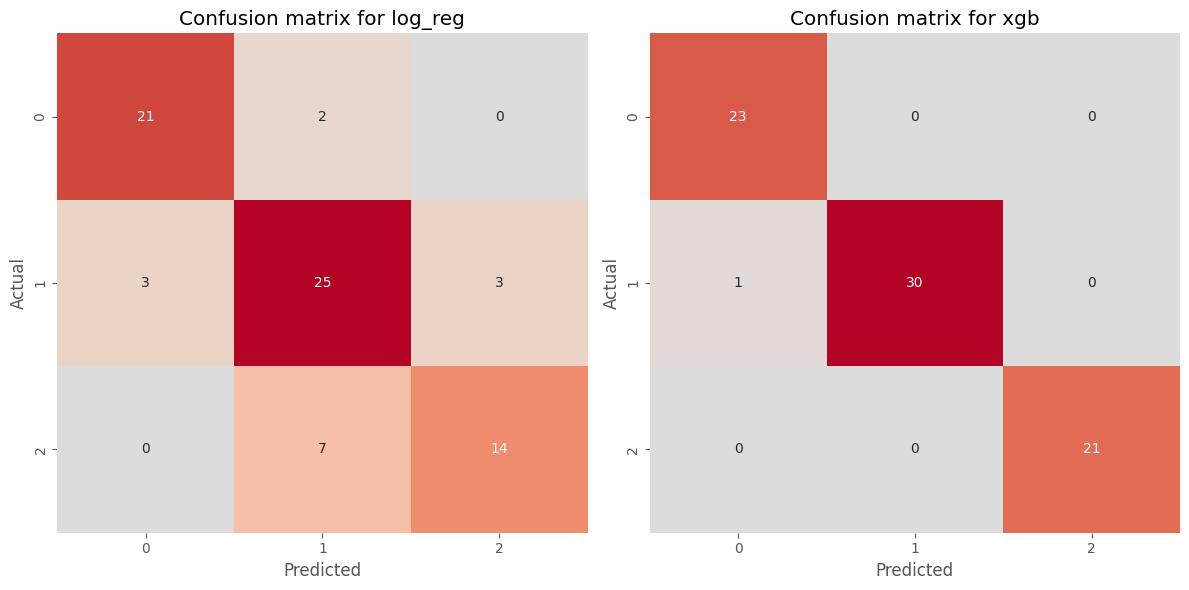

In [28]:
plt.figure(figsize=(12, 6))

for count, (name, model) in enumerate(models.items()):
    plt.subplot(1, 2, count + 1)
    cm = confusion_matrix(y_true= y_test, y_pred= predictions[name])
    sns.heatmap(cm, annot = True, fmt = 'd', cmap= 'coolwarm', cbar = False,
                center = 0)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion matrix for {name}')

plt.tight_layout()
plt.show()

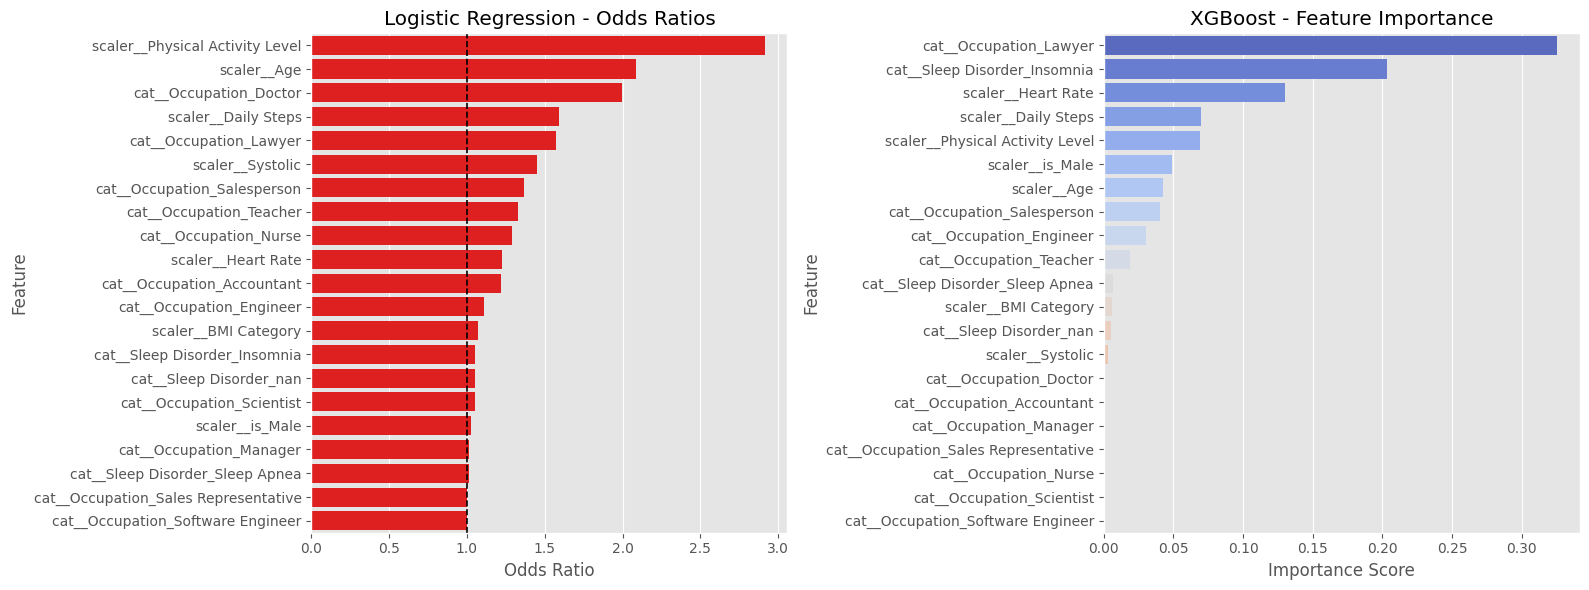

In [ ]:
feature_names = models['log_reg'].named_steps['preprocessor'].get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Log Reg
log_reg_model = models['log_reg'].named_steps['classifier']
odds_ratios = np.exp(log_reg_model.coef_).mean(axis=0)  # mean across 3 classes

lr_df = pd.DataFrame({
    "feature": feature_names,
    "odds_ratio": odds_ratios
}).sort_values("odds_ratio", ascending=False)

colors = ["red" if x > 1 else "green" for x in lr_df["odds_ratio"]]
sns.barplot(x="odds_ratio", y="feature", data=lr_df, ax=axes[0],
            hue="feature", palette=dict(zip(lr_df["feature"], colors)), legend=False)
axes[0].axvline(x=1, color="black", linestyle="--", linewidth=1.2)
axes[0].set_title("Logistic Regression - Odds Ratios")
axes[0].set_xlabel("Odds Ratio")
axes[0].set_ylabel("Feature")

# Xgboost
xgb_model = models['xgb'].named_steps['classifier']
importances = xgb_model.feature_importances_

xgb_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

sns.barplot(x="importance", y="feature", data=xgb_df, ax=axes[1],
            hue="feature", palette="coolwarm", legend=False)
axes[1].set_title("XGBoost - Feature Importance")
axes[1].set_xlabel("Importance Score")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

### Classification Result

It looks like our results is very good, maybe too good to be viable. Afterall, this is a *synthetic* dataset, so this kind of results is not unexpected


Let's try regression, see how accurate can we get from that approach

## Regression

In [30]:
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression


num_feature = [
        "Physical Activity Level",
        # "Stress Level",
        "Heart Rate",
        "Daily Steps",
        "Systolic",
        # "Diastolic",
        "Age",
        "BMI Category",
        'is_Male'
    ]

cat_feature =[
    'Occupation',
    'Sleep Disorder'
]

X = df[num_feature + cat_feature]
y = df['Sleep Duration']



X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 8, train_size= 0.8)


print(f"train shape: {X_train.shape}")
print(f"test shape: {X_test.shape}")


train shape: (299, 9)
test shape: (75, 9)


In [31]:


models = {
    'lin_reg': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression(
        ))
    ]),
    'xgb': Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(
    n_estimators=200,
    random_state = 8
    ))
    ])
}

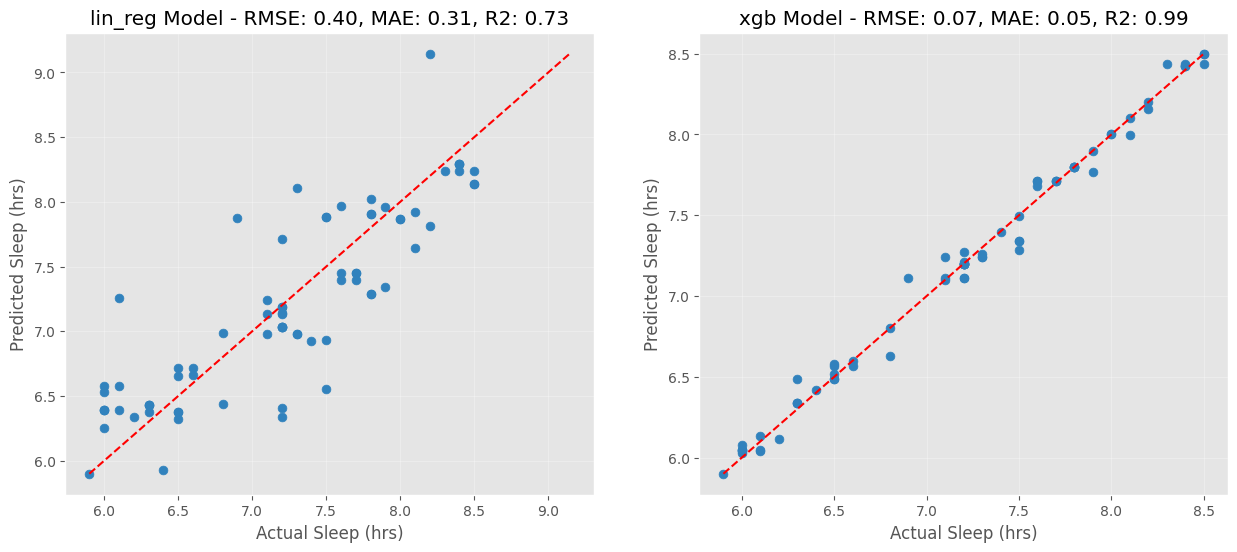

In [32]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

plt.figure(figsize= (15 ,6))
for count, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2= r2_score(y_test, y_pred)


    plt.subplot(1 , 2, count + 1)

    plt.scatter(y_test, y_pred , color='#3182bd', s=40)

    # 45-degree reference line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.xlabel('Actual Sleep (hrs)')
    plt.ylabel('Predicted Sleep (hrs)')
    plt.title(f'{name} Model - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}')
    plt.grid(alpha=0.3)





### Regression Result

* The **XGBoost model** is the clear winner, explaining **99%** of the variance in sleep duration ($R^2 = 0.99$). An MAE of 0.05 means its predictions are, on average, only about 3 minutes off from the actual sleep time.
* The Linear Regression model, while decent ($R^2 = 0.73$), shows much higher variance. You can see the blue dots are significantly more "scattered" away from the red dashed line compared to the XGBoost plot.



#### TLDR
The **XGBoost** model performs the best

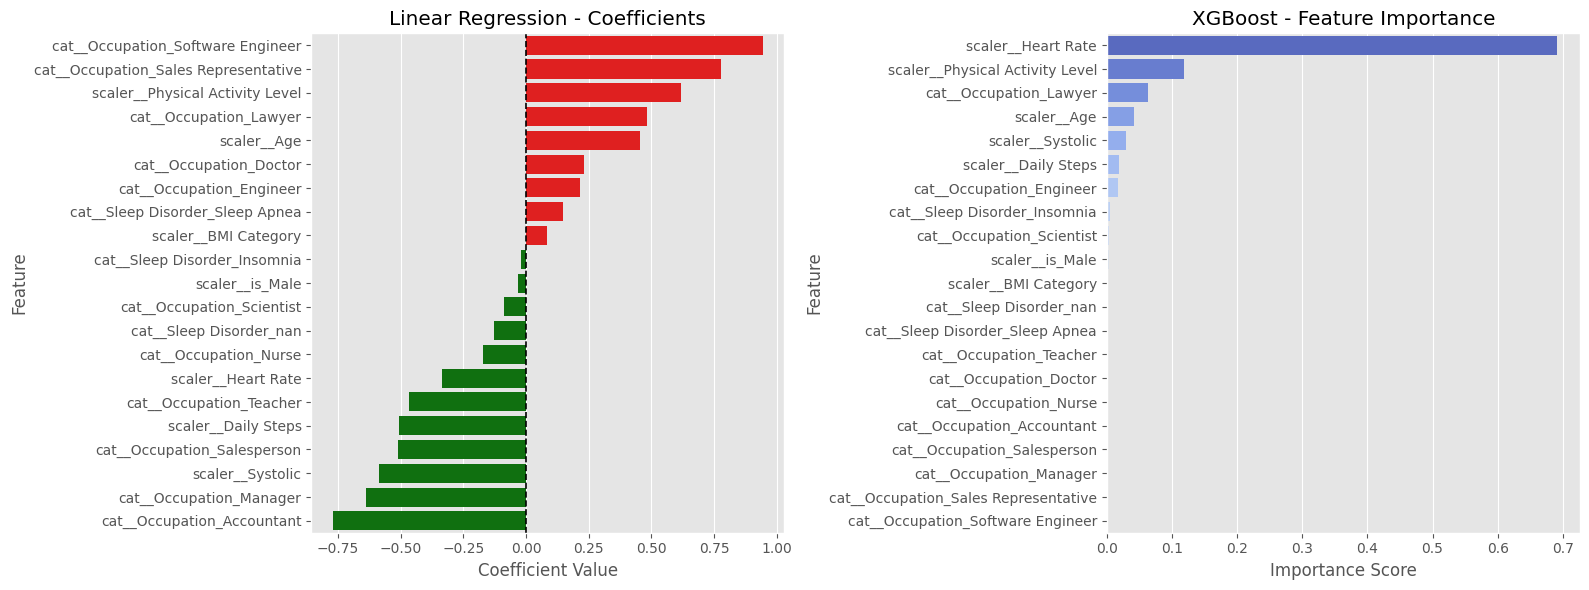

In [33]:
feature_names = models['lin_reg'].named_steps['preprocessor'].get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


lr_model = models['lin_reg'].named_steps['model']
coefficients = lr_model.coef_  

lr_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)

colors = ["red" if x > 0 else "green" for x in lr_df["coefficient"]]
sns.barplot(x="coefficient", y="feature", data=lr_df, ax=axes[0],
            hue="feature", palette=dict(zip(lr_df["feature"], colors)), legend=False)
axes[0].axvline(x=0, color="black", linestyle="--", linewidth=1.2)
axes[0].set_title("Linear Regression - Coefficients")
axes[0].set_xlabel("Coefficient Value")
axes[0].set_ylabel("Feature")

# Xgboost
xgb_model = models['xgb'].named_steps['model']
importances = xgb_model.feature_importances_

xgb_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

sns.barplot(x="importance", y="feature", data=xgb_df, ax=axes[1],
            hue="feature", palette="coolwarm", legend=False)
axes[1].set_title("XGBoost - Feature Importance")
axes[1].set_xlabel("Importance Score")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

## Clustering

Now let's pick out some features to see how about our clustering task.

I picked these since they are not within the *targeting features* (I want to use clustering to find out about `Sleep Illnes`, `Sleep Duration`, `Occupation`)

In [35]:
features_to_cluster = [ 'Age', 'Physical Activity Level', 'Stress Level',
                       'Heart Rate', 'BMI Category']

scaler = StandardScaler().set_output(transform="pandas")


X_cluster = scaler.fit_transform(df[features_to_cluster])

X_cluster.head(5)


,Age,Physical Activity Level,Stress Level,Heart Rate,BMI Category
0,-1.753096,-0.825418,0.347021,1.654719,1.004126
1,-1.637643,0.039844,1.475592,1.170474,-0.818899
2,-1.637643,0.039844,1.475592,1.170474,-0.818899
3,-1.637643,-1.402260,1.475592,3.591698,2.827150
4,-1.637643,-1.402260,1.475592,3.591698,2.827150


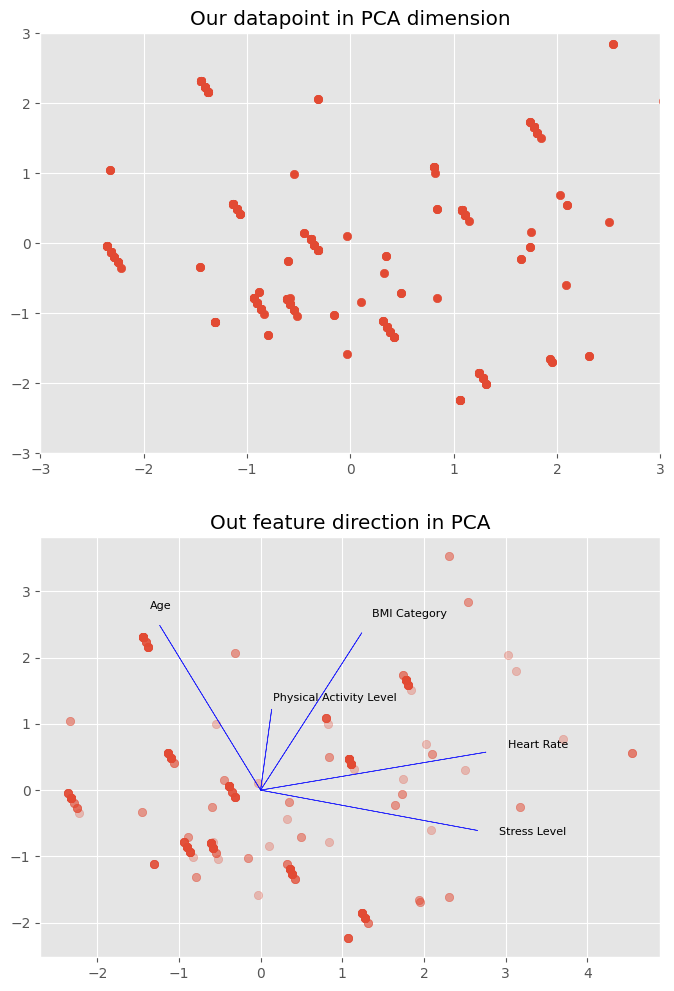

In [ ]:
from sklearn.decomposition import PCA
# Make graph bigger to see
scale_factor = 3

pca = PCA(n_components= 2).set_output(transform="pandas")

pca_data = pca.fit_transform(X_cluster)

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize= (8 , 12))
plt.subplot(2, 1, 1)

plt.scatter(pca_data.iloc[:, 0], pca_data.iloc[:, 1])
plt.title("Our datapoint in PCA dimension")

plt.xlim(-scale_factor, scale_factor)
plt.ylim(-scale_factor, scale_factor)

plt.subplot(2, 1, 2)
plt.scatter(pca_data.iloc[:, 0], pca_data.iloc[:, 1], alpha = 0.3)

for i, feature in enumerate(features_to_cluster):
    x_val = loadings[i, 0] * scale_factor
    y_val = loadings[i, 1] * scale_factor
    plt.arrow(0, 0, x_val, y_val,
              color = 'blue', alpha = 0.8)

    plt.text(x_val * 1.1, y_val * 1.1, feature, color='black', fontsize=8)



plt.title("Out feature direction in PCA")
plt.show()

Based on the direction of PCA, we can see that 
- `Heart Rate` correlates well with `Stress level`
- `BMI` and `Physical Activity` correlate well
- `Age` is just on its own

Next we will use Elbow method to find the optimal K for our clustering

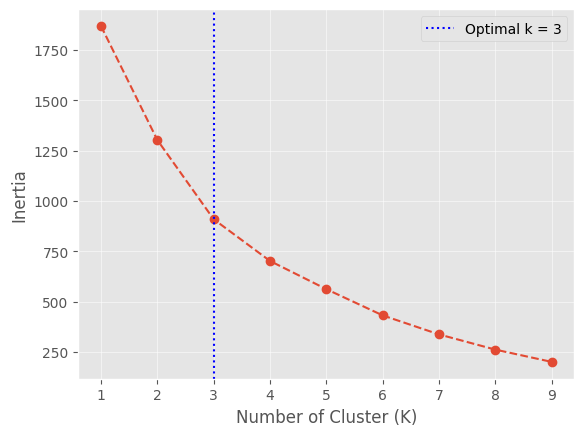

In [37]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters= k, random_state= 8, n_init= 10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)


kl = KneeLocator(K_range, inertia, curve= 'convex', direction= 'decreasing')
optimal_k = kl.elbow

plt.plot(K_range, inertia, marker = 'o', linestyle = '--')
plt.axvline(optimal_k, color = 'blue', linestyle = ':',
             label= f"Optimal k = {optimal_k}")

plt.xlabel('Number of Cluster (K)')
plt.ylabel('Inertia')
plt.legend()
plt.grid(alpha = 0.5)

plt.show()


In [38]:

kmeans_3 = KMeans(n_clusters=3, random_state=8, n_init=10)
df['Cluster'] = kmeans_3.fit_predict(X_cluster).astype(int)

profile = df.groupby('Cluster')[features_to_cluster].mean()
print("--- 3 Clusters Profile ---")
print(profile)

--- 3 Clusters Profile ---
               Age  Physical Activity Level  Stress Level  Heart Rate  \
Cluster                                                                 
0        52.178947                51.315789      3.357895   66.157895   
1        44.642105                61.031579      7.136842   75.031579   
2        35.755435                62.266304      5.527174   69.722826   

         BMI Category  
Cluster                
0            0.642105  
1            1.105263  
2            0.010870  


### Cluster Behavioral Profiles

* **Cluster 0: Low-Strain Mature Adults**
  * Low `stress`, high `age`

* **Cluster 1: High-Strain Adults**
  * High stress, middle `age`, high physical performance

* **Cluster 2: Early Youth**
  * High physical performance and optimal body composition, middle `stress`


In [ ]:
cluster_map = {
    0: 'Chill Seniors',
    1: 'Midlife',
    2: 'Early Youth'
}

df['Cluster_Profile'] = df['Cluster'].map(cluster_map)
print(df['Cluster_Profile'].value_counts())

Cluster_Profile
Early Youth      184
Midlife           95
Chill Seniors     95
Name: count, dtype: int64


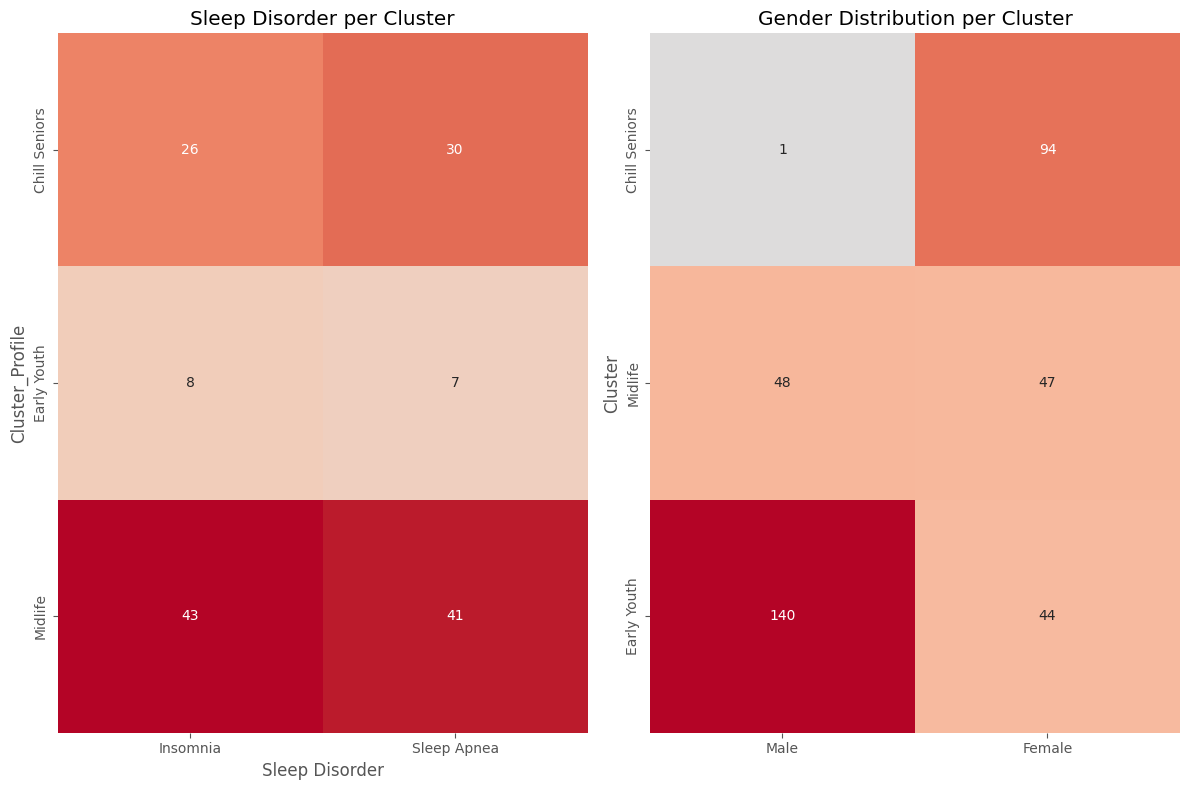

In [40]:
# Sleep Disorder per Cluster
cluster_disorders = pd.crosstab(df['Cluster_Profile'], df['Sleep Disorder'])

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
sns.heatmap(cluster_disorders, cmap='coolwarm', center=0, annot=True, fmt='d', cbar=False)
plt.title("Sleep Disorder per Cluster")

# Gender per Cluster — keep original is_Male logic
plt.subplot(1, 2, 2)
counts = df.groupby('Cluster')['is_Male'].agg(['count', 'sum'])
counts.columns = ['Total', 'Male']
counts['Female'] = counts['Total'] - counts['Male']
plot_data = counts[['Male', 'Female']]
plot_data.index = plot_data.index.map(cluster_map)

sns.heatmap(plot_data, cmap='coolwarm', annot=True, center=0, fmt='d', cbar=False)
plt.title('Gender Distribution per Cluster')
plt.tight_layout()
plt.show()

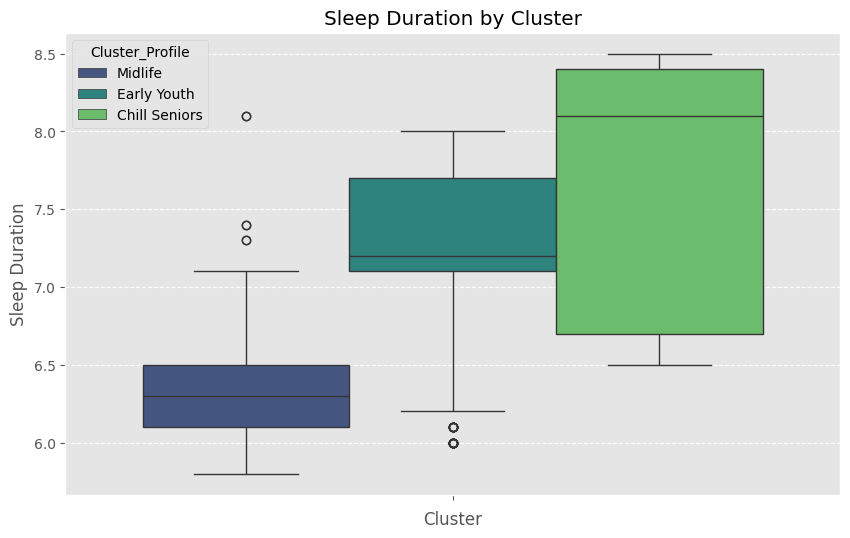

In [45]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, hue='Cluster_Profile', y='Sleep Duration', palette='viridis')
plt.xlabel("Cluster")
plt.ylabel("Sleep Duration")
plt.title("Sleep Duration by Cluster")
plt.grid(axis='y', linestyle='--')
plt.show()

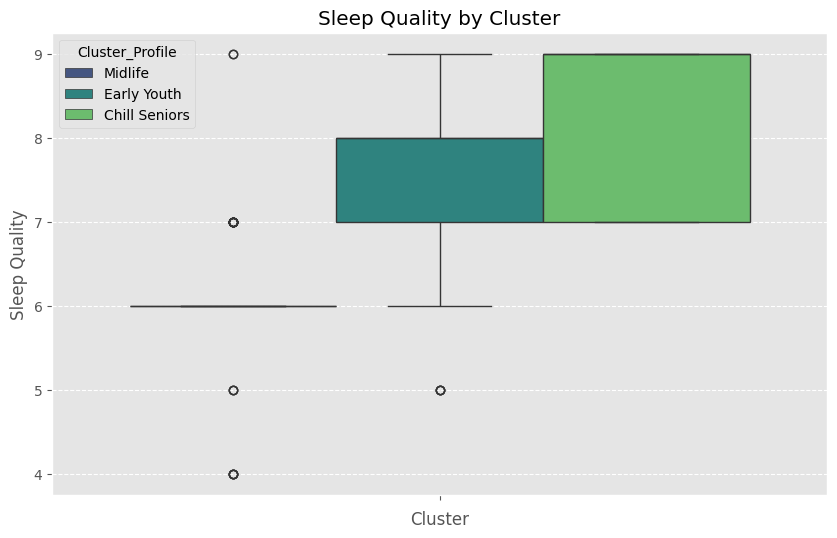

In [47]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, hue='Cluster_Profile', y='Quality of Sleep', palette='viridis')
plt.xlabel("Cluster")
plt.ylabel("Sleep Quality")
plt.title("Sleep Quality by Cluster")
plt.grid(axis='y', linestyle='--')
plt.show()

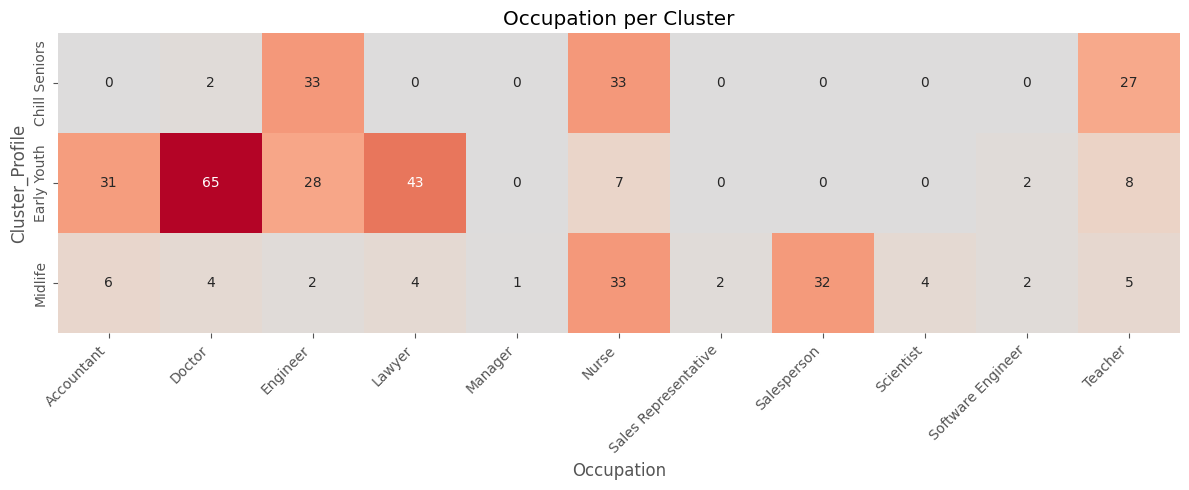

In [43]:
occupation_counts = pd.crosstab(df['Cluster_Profile'], df['Occupation'])

plt.figure(figsize=(12, 5))
sns.heatmap(occupation_counts, cmap='coolwarm', center=0, annot=True, fmt='d', cbar=False)
plt.title("Occupation per Cluster")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

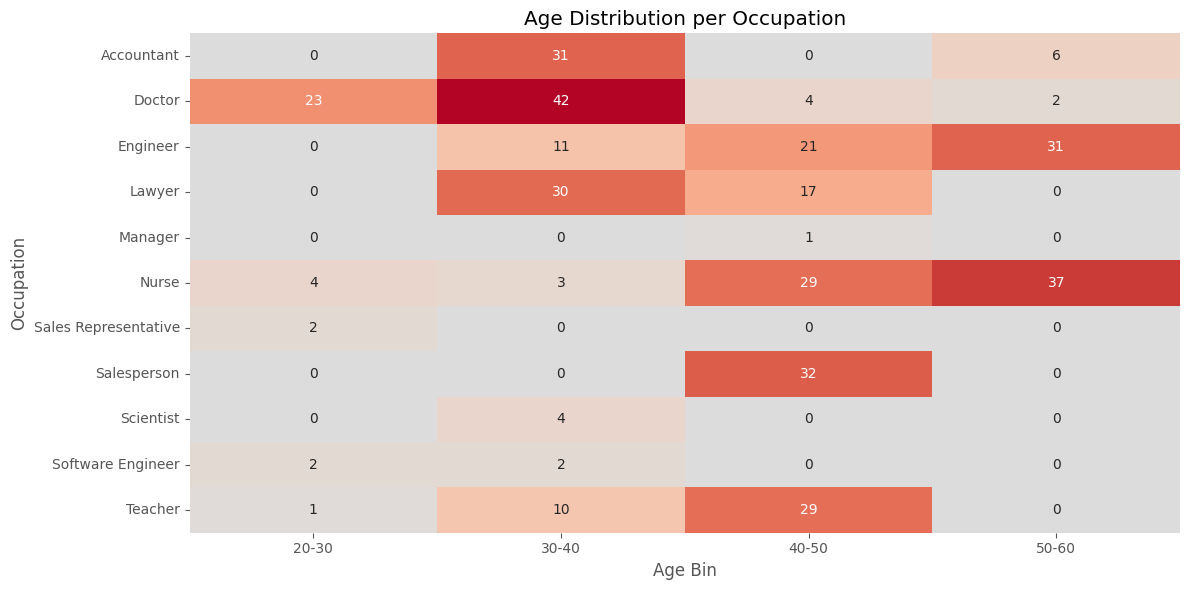

In [44]:
# Create age bins
df['Age Bin'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60], labels=['20-30', '30-40', '40-50', '50-60'])

# Crosstab occupation vs age bin
age_occupation = pd.crosstab(df['Occupation'], df['Age Bin'])

plt.figure(figsize=(12, 6))
sns.heatmap(age_occupation, cmap='coolwarm', center=0, annot=True, fmt='d', cbar=False)
plt.title("Age Distribution per Occupation")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Cluster Behavioral Profiles

**Cluster 0: Chill Seniors** (n=95)
- Oldest group (Age ~52), lowest stress (3.4), lowest heart rate (66)
- Lowest physical activity (51) but slightly overweight BMI (0.64)
- Best sleep duration (8.4hrs) and highest sleep quality (9.0)
- Almost entirely Female (1 Male, 94 Female)
- Decently high rates of Sleep Apnea (30) and Insomnia (26) — despite best sleep quality,
  suggesting disorders are managed or compensated by age-related sleep patterns

**Cluster 1: Midlife** (n=95)
- Middle-aged (44), highest stress (7.1), highest heart rate (75)
- Moderate activity (61), overweight BMI (1.1)
- Poor sleep duration (6.3hrs)
- Balanced gender (48M, 47F)
- Highest sleep disorder rates — Insomnia (43) and Sleep Apnea (41)
- Most at-risk cluster overall

**Cluster 2: Early Youth** (n=184)
- Youngest group (Age ~36), moderate stress (5.5), normal BMI (0.01)
- Highest physical activity (62), healthy heart rate (70)
- Moderate sleep duration (7.7hrs)
- Heavily Male (140M, 44F)
- Lowest sleep disorder rates (Insomnia: 8, Sleep Apnea: 7)

### Key Takeaways
- Sleep quality improves with age and lower stress (Chill Seniors sleep best)
- High stress + middle age = worst sleep disorders (Midlife cluster)
- Youth and fitness alone don't guarantee good sleep (Early Youth moderate sleep despite best BMI)
- Gender is heavily skewed — Early Youth is male-dominated, Chill Seniors almost entirely female

### Limitations
- **Occupation is confounded by age** — occupation distributions are not even across age 
  groups, so cluster differences in occupation reflect age skew rather than 
  occupation-specific sleep patterns.
- **Gender imbalance** — the heavy skew (Early Youth nearly all Male, Chill Seniors nearly 
  all Female) makes it difficult to separate gender effects from age and stress effects.
- **Cluster labels are interpretive** — KMeans assigns arbitrary numeric labels; the 
  descriptive names (Chill Seniors, Midlife, Early Youth) are human-assigned based on 
  mean feature values and may oversimplify within-cluster variation.
- **BMI encoding** — BMI Category was ordinally encoded (0=Normal, 1=Overweight, 2=Obese), 
  so mean BMI values (e.g. 0.01 for Early Youth) should be read as "nearly all Normal" 
  rather than a continuous measurement.